# Batch correction with Harmony

Harmony is the workhorse PCA-embedding integration method (Korsunsky et al., *Nat Methods* 2019). It runs entirely on the low-dimensional embedding, never touches the expression matrix, is the fastest of the lot, and is the only backend that works **out-of-core**.

This is one of the **omicverse batch-correction zoo** tutorials. See [batch/index](../index.md) for the overview / decision tree, or [../t_single_batch](../t_single_batch.ipynb) for the side-by-side comparison of every backend on a real benchmark.

## Load a 2-batch demo from pbmc3k

We use the canonical 10x pbmc3k dataset and synthesise a 2-batch label by random assignment, then plant a gene-shift on `batch_B` so the uncorrected UMAP shows a visible batch effect. This keeps the notebook self-contained and fast (~2 min end-to-end) — for a real multi-donor benchmark with [scib-metrics] scoring, see [../t_single_batch](../t_single_batch.ipynb).

In [1]:
import omicverse as ov
import scanpy as sc
import numpy as np
import pandas as pd

# Load the cached pbmc3k 10x raw counts (~2700 cells x ~32000 genes).
adata = ov.datasets.pbmc3k(processed=False)
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.layers['counts'] = adata.X.copy()  # scvi-tools needs raw counts here

# Synthesise a 2-batch demo: alternate cells, then plant a gene-shift on
# batch B so the uncorrected UMAP visibly separates by batch.
rng = np.random.default_rng(0)
batch = rng.choice(['batch_A', 'batch_B'], size=adata.n_obs, p=[0.5, 0.5])
adata.obs['batch'] = pd.Categorical(batch)

# Inject a multiplicative effect on the first 500 genes for batch_B.
from scipy.sparse import issparse, csr_matrix
X = adata.X.toarray() if issparse(adata.X) else adata.X.copy()
is_B = (adata.obs['batch'] == 'batch_B').values
X[is_B, :500] = X[is_B, :500] * 2.0
adata.X = csr_matrix(X)
adata.layers['counts'] = adata.X.copy()
adata

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


 Loading PBMC 3k dataset (raw)
⚠️ File ./data/pbmc3k_raw.h5ad already exists
 Loading data from ./data/pbmc3k_raw.h5ad
✅ Successfully loaded: 2700 cells × 32738 genes


AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'batch'
    var: 'gene_ids'
    layers: 'counts'

## Preprocess + PCA + cluster

Same QC → HVG-pearson → log-norm → PCA pipeline shared across every backend in the zoo. A quick Leiden cluster gives a synthetic `celltype` label that scANVI / scPoli can use as a prototype anchor.

In [2]:
# Standard omicverse preprocess (QC → HVG-via-pearson → log-norm → PCA).
adata = ov.pp.qc(adata, tresh={'mito_perc': 0.2, 'nUMIs': 500,
                                 'detected_genes': 250})
ov.utils.store_layers(adata, layers='counts')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000,
                         batch_key=None)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features].copy()
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)

# Quick Leiden cluster to use as a synthetic celltype label for scANVI etc.
sc.pp.neighbors(adata, use_rep='scaled|original|X_pca', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.5, flavor='igraph', directed=False,
             n_iterations=2)
adata.obs['celltype'] = adata.obs['leiden'].astype(str).map(
    lambda c: f'cluster_{c}'
).astype('category')
adata

🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 106                │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 13                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 0 cells, 19,024 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.417
   ✓ scDblFinder completed: 92 doublets removed (3.4%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 14.5489s                                                │
│  Shape:    2,700 x 32,738 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ 

/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/pp/_qc.py:1470: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['status'] = {}
/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/pp/_scale.py:158: UserWarning: Received a view of an AnnData. Making a copy.
  warn(msg, UserWarning)


   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,603 cells × 13,704 genes
   ✓ Runtime: 0.13s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 13,704 total (14.6%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.62 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/pp/_scale.py:737: UserWarning: zero-centering a sparse array/matrix densifies it.
  x, adata.var[str_mean_std[0]], adata.var[str_mean_std[1]] = scale_array(
/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/pp/_preprocess.py:1316: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__ <'1.10':


   🔧 PCA solver used: covariance_eigh
    finished✅ (18.02s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 18.0212s                                                │
│  Shape:    2,603 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 2603x30)                               │
│           │ ✚ scaled|original|X_pca (array, 2603x30)               │
│        

AnnData object with n_obs × n_vars = 2603 × 2000
    obs: 'batch', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'predicted_doublet', 'doublet_score', 'scdblfinder_doublet', 'scdblfinder_score', 'leiden', 'celltype'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'layers_counts', 'history_log', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

## Uncorrected baseline

The planted batch effect is visible in the uncorrected UMAP:

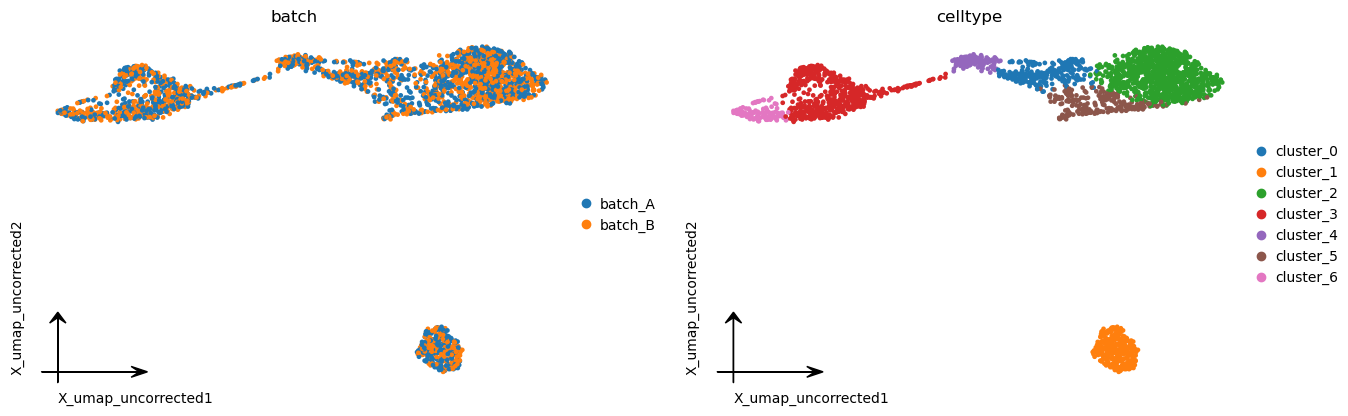

In [3]:
# Pre-correction UMAP shows the planted batch effect.
sc.tl.umap(adata, min_dist=0.3)
adata.obsm['X_umap_uncorrected'] = adata.obsm['X_umap'].copy()
ov.pl.embedding(adata, basis='X_umap_uncorrected',
                color=['batch', 'celltype'],
                frameon='small', wspace=0.5)

## Run `ov.single.batch_correction(methods='harmony')`

For the scvi-tools family backends, the wrapper auto-routes `**kwargs` between the model's `__init__` (architecture) and `.train()` (optimisation) destinations. See the **Key parameters** section below.

In [4]:
ov.single.batch_correction(
    adata,
    batch_key='batch',
    methods='harmony',
    n_pcs=30,
)

...Begin using harmony to correct batch effect
🖥️ Using NumPy CPU acceleration for Harmony
    Data: 30 PCs × 2603 cells
    Batch variables: ['batch']
    Max iterations: 10
    Convergence threshold: 0.0001
    Initializing centroids (K=87) ... 

done
🔍 [2026-05-29 00:50:07] Running Harmony integration...


Harmony iterations:   0%|                                                                                          | 0/10 [00:00<?, ?it/s]

Harmony iteration 1/10:   0%|                                                                                      | 0/10 [00:01<?, ?it/s]

Harmony iteration 1/10:  10%|███████▊                                                                      | 1/10 [00:01<00:09,  1.10s/it]

...

Harmony iteration 5/10:  50%|███████████████████████████████████████                                       | 5/10 [00:03<00:03,  1.63it/s]

Harmony iteration 6/10:  50%|███████████████████████████████████████                                       | 5/10 [00:04<00:03,  1.63it/s]

Harmony converged after 6 iterations:  50%|████████████████████████████████                                | 5/10 [00:04<00:03,  1.63it/s]

Harmony converged after 6 iterations:  50%|████████████████████████████████                                | 5/10 [00:04<00:04,  1.19it/s]


✅ Harmony converged after 6 iterations

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 4.4948s                                                 │
│  Shape:    2,603 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ X_harmony (array, 2603x30)                           │
│           │ ✚ X_pca_harmony (array, 2603x30)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


## Corrected embedding

Every backend writes its corrected representation to a stable obsm key — for this one it is `adata.obsm['X_pca_harmony']`. We project via `ov.utils.mde` for a lightweight UMAP-style display.

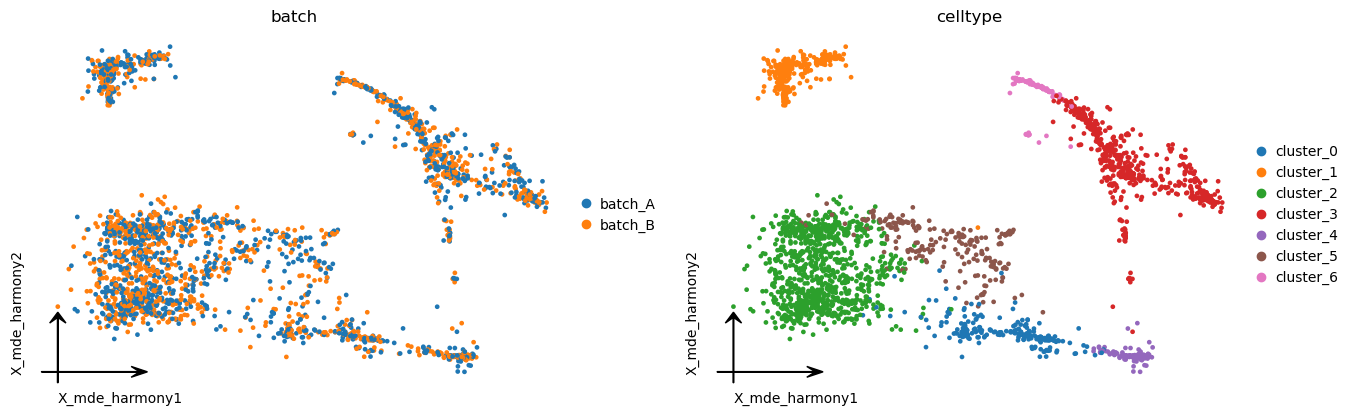

In [5]:
adata.obsm['X_mde_harmony'] = ov.utils.mde(adata.obsm['X_pca_harmony'])
ov.pl.embedding(
    adata,
    basis='X_mde_harmony',
    color=['batch', 'celltype'],
    frameon='small',
    wspace=0.5,
)

## Key parameters

- `n_pcs` — number of PCs Harmony iterates over (default 50).
- `theta` (advanced, via `**kwargs`) — diversity-clustering penalty.
- `use_rep` — name of the input PCA embedding to correct.


## Related tutorials

- [t_batch_combat](t_batch_combat.ipynb) — when you need a corrected *expression matrix* instead.
- [t_batch_scvi](t_batch_scvi.ipynb) — deep-learning when batches differ in composition.

For the full side-by-side comparison with scib-metrics scoring, see [../t_single_batch](../t_single_batch.ipynb).